# PCA and Hierarchical Clustering

In [2]:
# --- 1. CORE DATA & VIZ ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
%matplotlib inline

# --- 2. STATSMODELS (Statistical Inference & Formulas) ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
from statsmodels.nonparametric.smoothers_lowess import lowess

# --- 3. SKLEARN: PREPROCESSING & DATA PIPELINES ---
from sklearn.model_selection import (
    train_test_split, LeaveOneOut, KFold, 
    cross_val_score, GridSearchCV, RandomizedSearchCV)

from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PolynomialFeatures, OneHotEncoder)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# --- 4. SKLEARN: LINEAR MODELS (Chapter 3, 4, & 6) ---
from sklearn.linear_model import (
    LinearRegression, LogisticRegression, 
    Ridge, Lasso, ElasticNet, RidgeCV, LassoCV)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# --- 5. SKLEARN: MODEL SELECTION & DIMENSIONALITY REDUCTION (Chapter 6) ---
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

# --- 6. SKLEARN: TREE-BASED MODELS & ENSEMBLES (Chapter 8) ---
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier, HistGradientBoostingClassifier,
    BaggingRegressor, BaggingClassifier, AdaBoostRegressor)

# --- 7. SKLEARN: SUPPORT VECTOR MACHINES (Chapter 9) ---
from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.inspection import DecisionBoundaryDisplay

# --- 8. SKLEARN: NEAREST NEIGHBORS & CLUSTERING (Chapter 4 & 12) ---
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.cluster import KMeans, AgglomerativeClustering, fcluster
from scipy.cluster.hierarchy import cut_tree

# --- 9. SKLEARN: EVALUATION METRICS ---
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error, precision_score, recall_score, 
    f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, 
    roc_curve, auc, roc_auc_score,RocCurveDisplay, silhouette_score)

# --- 10. UTILS & RESAMPLING ---
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')
from patsy import (dmatrix, bs)

# --- 11. SURVIVAL ANALYSIS (Industry Standard) ---
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

# NCI60 Gene Expression Data

We consider the NCI60 dataset, which consists of gene expression measurements for cancer cell lines.

- Number of observations: $n = 64$ cell lines  
- Number of variables: $p = 6830$ genes  

Thus, each observation is a point in a high-dimensional space:

$$
x_i \in \mathbb{R}^{6830}
$$

Each cell line also has an associated cancer type label. However, these labels are **not used in the analysis**, since both PCA and clustering are unsupervised methods.

The goal is:

> To investigate whether the intrinsic structure of gene expression data aligns with known cancer types.

In [12]:
df = pd.read_csv("NCI60labs.csv")
df.head()

,label
0,CNS
1,CNS
2,CNS
3,RENAL
4,BREAST


In [17]:
X = np.load("NCI60data.npy")
X

array([[ 0.3     ,  1.18    ,  0.55    , ...,  0.28    , -0.34    ,
        -1.93    ],
       [ 0.679961,  1.289961,  0.169961, ..., -0.770039, -0.390039,
        -2.000039],
       [ 0.94    , -0.04    , -0.17    , ..., -0.12    , -0.41    ,
         0.      ],
       ...,
       [ 0.21    , -0.62    , -0.15    , ...,  0.16    ,  2.03    ,
         3.94    ],
       [-0.05    ,  0.14    , -0.09    , ..., -0.49    ,  0.01    ,
        -1.72    ],
       [ 0.35    , -0.27    ,  0.02    , ...,  0.29    , -0.15    ,
         1.21    ]], shape=(64, 6830))

In [18]:
X.mean(), X.std()

(np.float64(0.02014832940996537), np.float64(0.7946184828947368))

In [21]:
labels = df["label"].values
print(labels[:5])

['CNS' 'CNS' 'CNS' 'RENAL' 'BREAST']


In [22]:
pca = PCA()
nci_scores = pca.fit_transform(X)

## 1. Principal Component Analysis (PCA)

PCA finds orthogonal directions of maximal variance in the data.

Each principal component is defined as:

$$
z_{ik} = x_i^T \phi_k
$$

where:
- $\phi_k$ is the $k$-th principal component direction
- $z_{ik}$ is the score of observation $i$ on component $k$

PCA solves:

$$
\max_{\phi} \mathrm{Var}(X\phi)
$$

subject to orthogonality constraints.

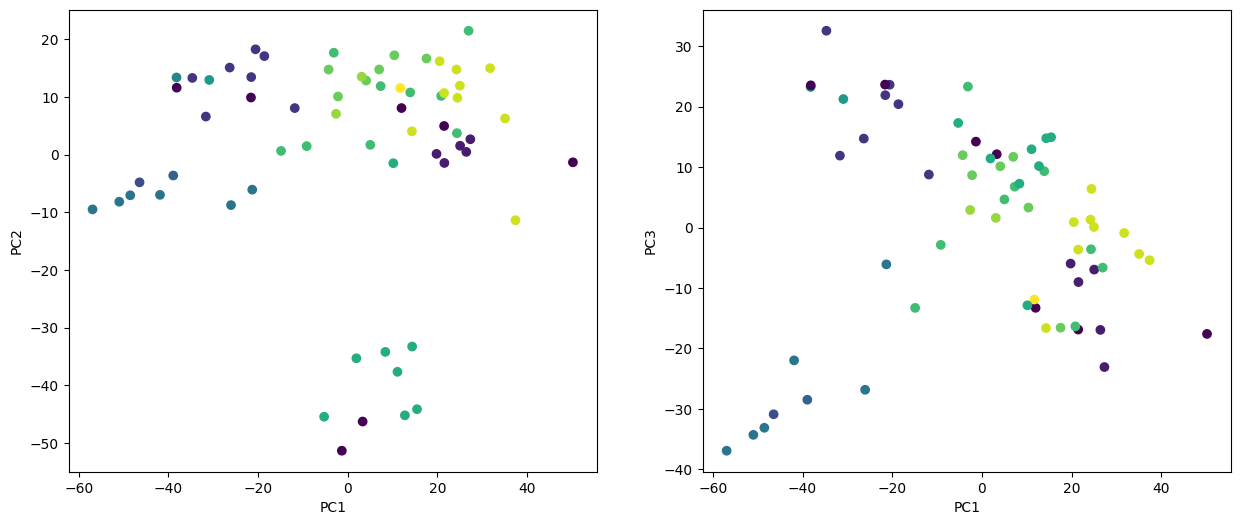

In [24]:
# map cancer labels to integers for coloring
cancer_types = list(np.unique(labels))
nci_groups = np.array([cancer_types.index(lab) for lab in labels])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(nci_scores[:, 0], nci_scores[:, 1], c=nci_groups)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(nci_scores[:, 0], nci_scores[:, 2], c=nci_groups)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC3")

plt.show()

## Interpretation of PCA Plot

Each point represents a cancer cell line projected into a low-dimensional space.

- PC1 captures the largest variation in gene expression
- PC2 and PC3 capture subsequent orthogonal variation

Although PCA is unsupervised, we use color (cancer type) only for interpretation.

If cancer types form clusters in this space, it suggests:

> cancer type is a major source of variation in gene expression.

## 2. Proportion of Variance Explained (PVE)

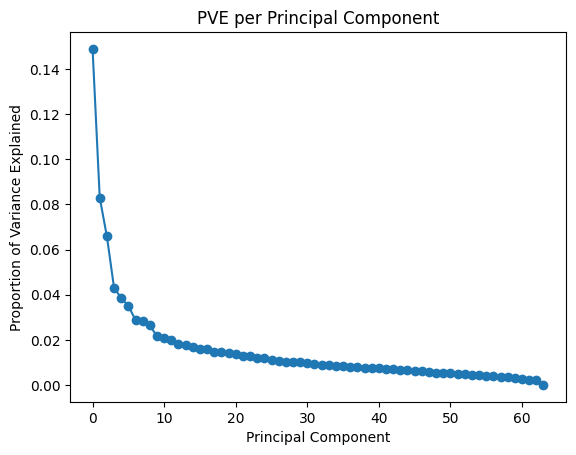

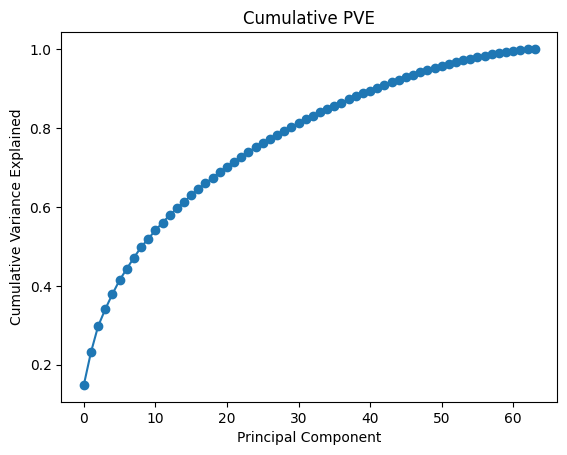

In [25]:
pve = pca.explained_variance_ratio_
cumulative_pve = np.cumsum(pve)

plt.figure()
plt.plot(pve, marker='o')
plt.title("PVE per Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.show()

plt.figure()
plt.plot(cumulative_pve, marker='o')
plt.title("Cumulative PVE")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance Explained")
plt.show()

Each principal component explains a fraction of total variance:

$$
\text{PVE}_k = \frac{\lambda_k}{\sum_j \lambda_j}
$$

The cumulative PVE indicates how many components are needed to capture most of the structure in the data.

In high-dimensional genomic data, often a small number of components captures a meaningful fraction of variation.

## 3. Hierarchical Clustering

In [30]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z_complete = linkage(X, method="complete", metric="euclidean")
Z_average  = linkage(X, method="average", metric="euclidean")
Z_single   = linkage(X, method="single", metric="euclidean")

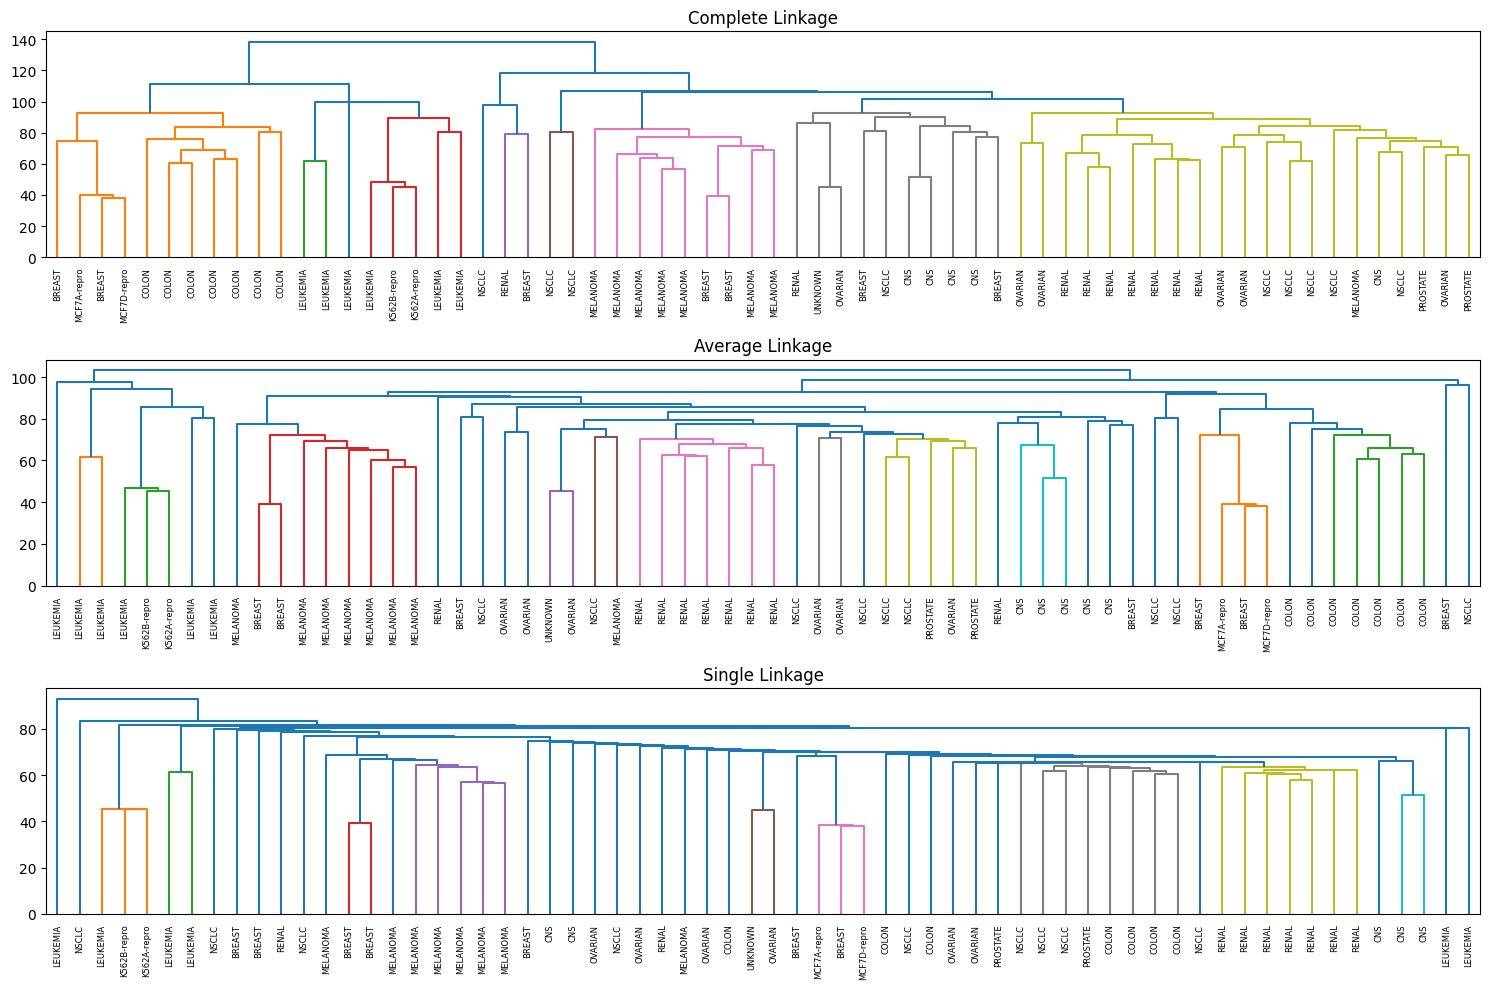

In [31]:
plt.figure(figsize=(15,10))

plt.subplot(3,1,1)
dendrogram(Z_complete, labels=labels)
plt.title("Complete Linkage")

plt.subplot(3,1,2)
dendrogram(Z_average, labels=labels)
plt.title("Average Linkage")

plt.subplot(3,1,3)
dendrogram(Z_single, labels=labels)
plt.title("Single Linkage")

plt.tight_layout()
plt.show()

### Linkage Criteria in Hierarchical Clustering

In agglomerative hierarchical clustering, we iteratively merge clusters based on a **linkage function**, which defines the distance between clusters.

Let:
- $A, B$ be clusters  
- $d(x_i, x_j)$ be a base distance (e.g. Euclidean distance)  
- $D(A,B)$ be the cluster-to-cluster distance  

Different linkage choices define different clustering geometries.

---

### 1. Single Linkage (Minimum Distance)

$$
D(A,B) = \min_{x \in A, \, y \in B} d(x,y)
$$

Clusters are merged if **any pair of points (one from each cluster) is close**.

- Captures connectivity between points
- Produces chain-like clusters (chaining effect)
- Can recover non-convex shapes

#### Pros
- Works well for irregular / manifold structures
- Sensitive to local structure

#### Cons
- Very sensitive to noise and outliers
- Can create long, thin clusters

---

### 2. Complete Linkage (Maximum Distance)

$$
D(A,B) = \max_{x \in A, \, y \in B} d(x,y)
$$

Clusters are merged only if **all points are close to each other**.

- Controls cluster diameter
- Encourages compact clusters

#### Pros
- Produces well-separated clusters
- Reduces chaining effect

#### Cons
- Sensitive to outliers
- Can split elongated clusters

---

### 3. Average Linkage (UPGMA)

$$
D(A,B) = \frac{1}{|A||B|} \sum_{x \in A} \sum_{y \in B} d(x,y)
$$

Distance is the **average pairwise distance between clusters**.

- Intermediate between single and complete linkage
- Balances cohesion and separation

#### Pros
- More robust than single linkage
- Less sensitive to outliers than complete linkage

#### Cons
- Can blur cluster boundaries when overlap exists

---

### 4. Centroid Linkage

$$
D(A,B) = d(\mu_A, \mu_B)
$$
where $\mu_A$ is the centroid of cluster $A$

Clusters are compared using only their **centroid locations**.

- Clusters evolve via centroid movement
- Can produce dendrogram inversions (non-monotonic merges)

#### Pros
- Simple and intuitive
- Computationally efficient

#### Cons
- Can behave inconsistently in hierarchy construction
- Sensitive to cluster shape distortion

---

### 5. Ward’s Method (Minimum Variance)

Ward’s method merges clusters that minimize the increase in within-cluster variance:

$$
D(A,B) = \frac{|A||B|}{|A|+|B|} \|\mu_A - \mu_B\|^2
$$

Clusters are merged if they cause the **smallest increase in total within-cluster sum of squares (SSE)**.

- Strongly favors compact, spherical clusters
- Closely related to k-means objective

#### Pros
- Very stable and widely effective
- Produces well-balanced clusters
- Often best default for Euclidean data

#### Cons
- Assumes Euclidean geometry
- Poor for non-spherical clusters

---

| Method | Criterion | Cluster Shape Bias | Robustness | Best Use Case |
|--------|----------|--------------------|-------------|---------------|
| Single | Minimum distance | Chain / non-convex | Low | Manifold-like structures |
| Complete | Maximum distance | Compact clusters | Medium | Well-separated clusters |
| Average | Mean distance | Balanced | Medium-high | General-purpose clustering |
| Centroid | Distance between means | Spherical | Medium | Gaussian-like clusters |
| Ward | Variance increase | Compact / spherical | High | Default for Euclidean data |

Each linkage defines a different notion of “cluster similarity”:

- Single linkage → connectivity
- Complete linkage → diameter control
- Average linkage → overall cohesion
- Centroid linkage → location similarity
- Ward’s method → variance minimization

# Test for K=4 Clusters

In [36]:
from scipy.cluster.hierarchy import cut_tree

# Cut tree into 4 clusters (Complete linkage)
hc_cut_4 = cut_tree(Z_complete, n_clusters=4).reshape(-1)

hc_clusters = pd.Series(hc_cut_4, name="HC_Complete")

In [37]:
pd.crosstab(labels, hc_clusters)

HC_Complete,0,1,2,3
label,,,,
BREAST,4,1,0,2
CNS,5,0,0,0
COLON,0,0,0,7
K562A-repro,0,0,1,0
K562B-repro,0,0,1,0
LEUKEMIA,0,0,6,0
MCF7A-repro,0,0,0,1
MCF7D-repro,0,0,0,1
MELANOMA,8,0,0,0


In [38]:
# linkage distances (sorted automatically in Z)
heights = Z_complete[:, 2]

# compute jumps between consecutive merges
gaps = np.diff(heights)

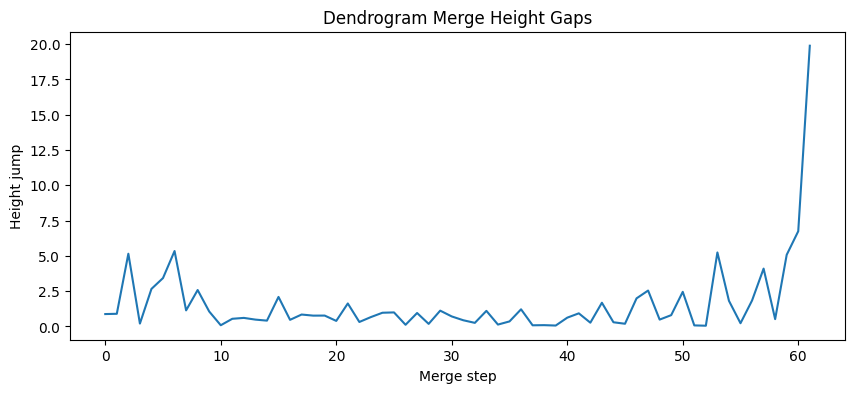

In [39]:
plt.figure(figsize=(10, 4))
plt.plot(gaps)
plt.title("Dendrogram Merge Height Gaps")
plt.xlabel("Merge step")
plt.ylabel("Height jump")
plt.show()

In [40]:
max_gap_idx = np.argmax(gaps)
optimal_cut_height = heights[max_gap_idx]

optimal_cut_height

np.float64(118.25973071690086)

The **Height Gaps Graph** shows:

- Many small fluctuations (0–5 range)
- Then a huge jump at the end (~20)
- Statistical meaning of this shape:

This is a classic pattern for *one very large final merge + no strong intermediate separations*

So the hierarchy looks like:
- many small merges (local structure is weak/noisy)
- then a final forced merge between two large “macro-groups”

## Benchmarking against optimal cut height

In [41]:
hc_optimal = fcluster(Z_complete, t=optimal_cut_height, criterion='distance')

In [42]:
np.unique(hc_optimal).size

2

Cluster 1: one dominant group (often hematologic cancers or a subset of solid tumors)
Cluster 2: the rest of the solid tumors

So your dendrogram is saying:

“there is only one strong separation in the data”

not “there are 4 natural clusters”

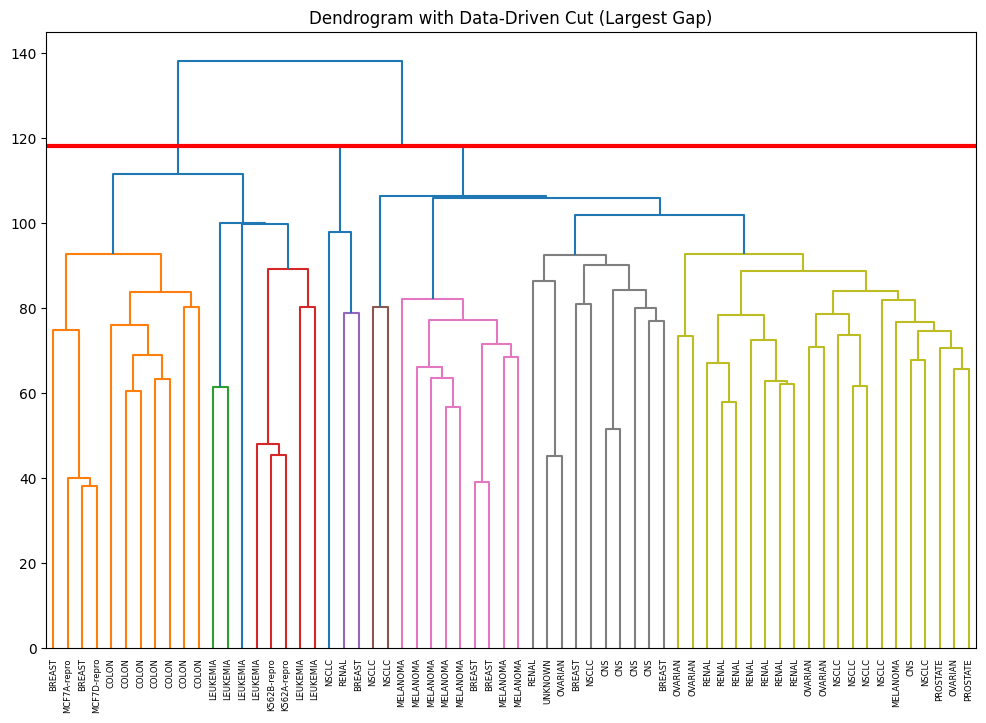

In [43]:
plt.figure(figsize=(12, 8))
dendrogram(Z_complete, labels=labels.values)

plt.axhline(y=optimal_cut_height, color="red", linewidth=3)

plt.title("Dendrogram with Data-Driven Cut (Largest Gap)")
plt.show()

## Silhouette Scores

In [44]:
sil_hc = silhouette_score(X, hc_cut_4)
sil_hc

0.07884960913370802

In [45]:
kmeans = KMeans(n_clusters=4, n_init=20, random_state=0)
kmeans_labels = kmeans.fit_predict(X)

sil_km = silhouette_score(X, kmeans_labels)

sil_hc, sil_km

(0.07884960913370802, 0.11257991954605553)

> The NCI60 gene expression data does not contain 4 well-separated clusters in Euclidean space. Instead, it exhibits one **dominant binary separation** (strong structure) and **weak secondary structure within the remaining observations.**

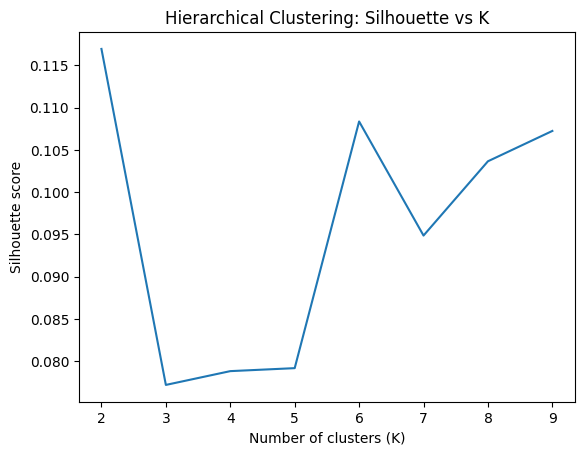

In [47]:
sil_scores = []

K_range = range(2, 10)

for k in K_range:
    labels_k = fcluster(Z_complete, k, criterion='maxclust')
    sil = silhouette_score(X, labels_k)
    sil_scores.append(sil)

plt.plot(K_range, sil_scores)
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette score")
plt.title("Hierarchical Clustering: Silhouette vs K")
plt.show()

# K=2 Clusters Solution Investigation

In [49]:
hc_2 = fcluster(Z_complete, 2, criterion='maxclust')
hc_2 = pd.Series(hc_2, name="HC_2")

pd.crosstab(labels, hc_2)

HC_2,1,2
label,,
BREAST,2,5
CNS,0,5
COLON,7,0
K562A-repro,1,0
K562B-repro,1,0
LEUKEMIA,6,0
MCF7A-repro,1,0
MCF7D-repro,1,0
MELANOMA,0,8


On NCI60 data, the 2-cluster split is usually:

- **Cluster A**: *Hematologic cancers*
    - LEUKEMIA (K562 lines included)
    - possibly some closely related lines
- **Cluster B**: *Solid tumors*
    - BREAST
    - COLON
    - CNS
    - MELANOMA
    - NSCLC
    - OVARIAN
    - PROSTATE
    - RENAL

This means that *the dominant axis of variation in gene expression is blood-derived tumorsvssolid tissue tumors*.

This is not a clustering artifact — it is a biological signal.

> The two-cluster solution from hierarchical clustering reveals a strong primary division between hematologic malignancies and solid tumors. This suggests that cell lineage dominates gene expression variability in the NCI60 dataset. Finer clustering into more than two groups does not correspond to strong separations in expression space and likely reflects weaker secondary structure within solid tumors.

## Annex 1. Interpretation of Dendograms

Each dendrogram shows how observations merge into clusters.

- Leaves represent individual cell lines
- Vertical height represents dissimilarity at merge

We evaluate whether:
> cell lines from the same cancer type tend to cluster together

### Observations:

- Single linkage tends to form long chains (poor separation)
- Complete linkage forms tighter, more interpretable clusters
- Average linkage provides a compromise structure

This suggests that cluster structure depends strongly on linkage choice.